# End-to-End Cascade — Stage 1 detection → Stage 2 subtype

`model_stage1_cnn1d_detection.ipynb` and `model_stage2_cnn1d_subtype.ipynb` were each
trained and evaluated **independently**: Stage 1 on raw 4 s windows, Stage 2 on 10 s windows
that are already known, ground-truth seizures. Neither notebook's output feeds the other.
This notebook wires them together and asks the question neither answered on its own: **if
you actually ran this as a pipeline -- Stage 1 flags a window, and only then does Stage 2
attempt to subtype it -- how well does the whole thing work?**

## Design

Stage 2 always classifies the *true*, correctly-windowed 10 s seizure segment when it runs --
this cascade does not attempt dynamic re-segmentation from Stage 1's raw window-level flags
(that would need a temporal event-proposal system, a materially bigger undertaking). The one
and only thing Stage 1 controls is the **gate**: does the pipeline even attempt Stage 2 for
this event? That isolates "Stage 1 missed the seizure entirely" from "Stage 2 windowed it
wrong", and keeps this notebook's job to answering the gating question honestly, not
re-solving segmentation.

## The held-out-set subtlety

Stage 1's test set (subject-level, 5 subjects) and Stage 2's LOSO folds (one held-out patient
per fold, all 13 usable Siena patients) were built independently, with no shared notion of
"the cascade test set." That means most patients evaluable here were **seen by Stage 1's own
training or early-stopping**, which makes Stage 1's detection numbers on them optimistic --
not a fair test of Stage 1 alone, only of the cascade's wiring and Stage 2's conditional
performance. Exactly **two** patients (`PN16`, `PN17`) happen to be both a Stage 1 test
subject *and* have a Stage 2 LOSO fold -- the only genuinely doubly-held-out evaluation
available from what's already trained. Both groups are reported, clearly labelled:

- **Strict** (`PN16`, `PN17`): fully honest, but n=2 patients / a handful of events.
- **Broad** (all 13 Stage-2-usable patients): more events, but each patient's Stage-1-role
  (train / val / test) is reported alongside its numbers so the read is never accidentally
  taken as a blind test.

## Config

In [1]:
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
STAGE1_CKPT = Path("../checkpoints/stage1_cnn1d_detection/best_model.pt")
STAGE2_CKPT_DIR = Path("../checkpoints/stage2_cnn1d_subtype")
OUT_DIR = Path("../checkpoints/cascade_end_to_end")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 20260803
# Must match model_stage1_cnn1d_detection.ipynb's config -- recovers the exact same
# train/val/test subject split from the same seed, since it isn't saved anywhere else.
STAGE1_SPLIT_FRACS = (0.70, 0.15)

# Stage 1 decision threshold: the best-F1 operating point from that notebook's own
# threshold sweep. Change here to explore other operating points on the ROC curve.
STAGE1_THRESHOLD = 0.73
# An event counts as "detected" once at least this fraction of its Stage-1 windows are
# predicted positive. 1 window / n would be "any window flags it"; 0.5 would be "majority".
DETECTION_MIN_FRACTION = 0.3

# Stage 2 architecture -- must match model_stage2_cnn1d_subtype.ipynb. Its checkpoints are
# raw state_dicts (unlike Stage 1's, which embed their own config), so this has to be
# specified again here rather than read back from the checkpoint file.
STAGE2_WIDTH = 16
STAGE2_DROPOUT = 0.5

# Background (non-seizure) windows are subsampled per patient for the false-positive /
# "garbage in" check below -- there are tens of thousands of them; this bounds runtime
# without materially changing the false-positive rate estimate.
MAX_BACKGROUND_PER_PATIENT = 2000
FALSE_POSITIVE_PROBE_SAMPLE = 40   # of the false positives found, how many to run through Stage 2

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))


device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data, and recovering Stage 1's train/val/test split

`subject_split` is copied verbatim from `model_stage1_cnn1d_detection.ipynb` -- with the same
seed and the same input table, it deterministically reproduces the exact subject sets that
notebook trained on, so this notebook can label every patient's Stage-1 relationship without
Stage 1 needing to have saved that split anywhere.

In [2]:
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
N_CLASSES = len(CLASS_NAMES)
N1_TIMEPOINTS = int(round(MANIFEST["stage1"]["window_s"] * MANIFEST["sfreq"]))
N2_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
print(f"Stage 1 windows: {N1_TIMEPOINTS} samples | Stage 2 windows: {N2_TIMEPOINTS} samples")

def subject_split(df, train_frac, val_frac, seed):
    rng = np.random.default_rng(seed)
    train_s, val_s, test_s = set(), set(), set()
    for dataset, g in df.groupby("dataset"):
        subs = rng.permutation(sorted(g.subject_key.unique()))
        n = len(subs)
        n_train = max(1, int(round(n * train_frac)))
        n_val = max(1, int(round(n * val_frac)))
        train_s.update(subs[:n_train])
        val_s.update(subs[n_train:n_train + n_val])
        test_s.update(subs[n_train + n_val:])
    return train_s, val_s, test_s

stage1_train_subj, stage1_val_subj, stage1_test_subj = subject_split(S1, *STAGE1_SPLIT_FRACS, SEED)

def stage1_role(subject_key):
    if subject_key in stage1_test_subj:
        return "test (unseen by Stage 1)"
    if subject_key in stage1_val_subj:
        return "val (Stage 1 early-stop signal)"
    return "train (fully seen by Stage 1)"

stage2_patients = sorted(S2.subject.unique())
patient_roles = {p: stage1_role(f"SienaScalp/{p}") for p in stage2_patients}
strict_patients = [p for p, r in patient_roles.items() if r.startswith("test")]

print("Stage-1 role for each Stage-2-usable Siena patient:")
for p in stage2_patients:
    print(f"  {p}: {patient_roles[p]}")
print(f"\nStrict doubly-held-out set: {strict_patients}")


Stage 1 windows: 1024 samples | Stage 2 windows: 2560 samples
Stage-1 role for each Stage-2-usable Siena patient:
  PN00: train (fully seen by Stage 1)
  PN01: train (fully seen by Stage 1)
  PN03: train (fully seen by Stage 1)
  PN05: train (fully seen by Stage 1)
  PN06: train (fully seen by Stage 1)
  PN07: train (fully seen by Stage 1)
  PN09: train (fully seen by Stage 1)
  PN10: train (fully seen by Stage 1)
  PN12: train (fully seen by Stage 1)
  PN13: val (Stage 1 early-stop signal)
  PN14: val (Stage 1 early-stop signal)
  PN16: test (unseen by Stage 1)
  PN17: test (unseen by Stage 1)

Strict doubly-held-out set: ['PN16', 'PN17']


## Models

Both architectures reproduced exactly as trained -- shapes must match for the saved weights
to load. Stage 1 loads once (a single model); Stage 2 loads all 13 per-patient LOSO
checkpoints, since each patient's honestly-held-out prediction requires the fold where
*that* patient was the one held out.

In [3]:
class SeizureCNN1D(nn.Module):
    def __init__(self, n_channels=18, n_classes=1, width=32, dropout=0.3):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(0.1),
            )

        self.features = nn.Sequential(
            block(n_channels, width, 63, 2), block(width, width * 2, 31, 2),
            block(width * 2, width * 4, 15, 2), block(width * 4, width * 8, 7, 2),
            block(width * 8, width * 8, 3, 1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 8, width * 4), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width * 4, width), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width, n_classes),
        )

    def forward(self, x):
        return self.head(self.pool(self.features(x)))


class SubtypeCNN1D(nn.Module):
    def __init__(self, n_channels=18, n_classes=3, width=24, dropout=0.4):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(0.1),
            )

        self.features = nn.Sequential(
            block(n_channels, width, 63, 2), block(width, width * 2, 31, 2),
            block(width * 2, width * 4, 15, 2), block(width * 4, width * 8, 7, 2),
            block(width * 8, width * 8, 3, 1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 8, width * 4), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(width * 4, n_classes),
        )

    def forward(self, x):
        return self.head(self.pool(self.features(x)))


In [4]:
ckpt1 = torch.load(STAGE1_CKPT, map_location=DEVICE, weights_only=False)
stage1_model = SeizureCNN1D(ckpt1["config"]["n_channels"], n_classes=1,
                             width=ckpt1["config"]["width"], dropout=ckpt1["config"]["dropout"]).to(DEVICE)
stage1_model.load_state_dict(ckpt1["model_state"])
stage1_model.eval()
print(f"Stage 1 loaded: epoch {ckpt1['epoch']}, val AUROC {ckpt1['val_auc']:.4f}")

stage2_models = {}
for p in stage2_patients:
    m = SubtypeCNN1D(N_CH, N_CLASSES, STAGE2_WIDTH, STAGE2_DROPOUT).to(DEVICE)
    m.load_state_dict(torch.load(STAGE2_CKPT_DIR / f"real_fold_{p}.pt", map_location=DEVICE, weights_only=False))
    m.eval()
    stage2_models[p] = m
print(f"Stage 2 loaded: {len(stage2_models)} per-patient LOSO checkpoints")


Stage 1 loaded: epoch 8, val AUROC 0.7804


Stage 2 loaded: 13 per-patient LOSO checkpoints


## Loading + running windows

Same lazy HDF5 read + per-channel z-score normalization used throughout -- see
`preprocessing.ipynb` and either stage notebook for why.

In [5]:
def load_windows(df, n_timepoints):
    X = np.empty((len(df), N_CH, n_timepoints), dtype=np.float32)
    cache = {}
    for i, row in enumerate(df.itertuples(index=False)):
        f = cache.get(row.path)
        if f is None:
            f = h5py.File(row.path, "r")
            cache[row.path] = f
        sig = f["signal"]
        start = int(row.start)
        end = min(start + n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < n_timepoints:
            w = np.pad(w, ((0, 0), (0, n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        X[i] = (w - mu) / sd
    for f in cache.values():
        f.close()
    return torch.from_numpy(X)


@torch.no_grad()
def stage1_predict_proba(df, batch_size=256):
    probs = np.empty(len(df), dtype=np.float32)
    for start in range(0, len(df), batch_size):
        chunk = df.iloc[start:start + batch_size]
        X = load_windows(chunk, N1_TIMEPOINTS).to(DEVICE)
        logits = stage1_model(X).squeeze(-1)
        probs[start:start + len(chunk)] = torch.sigmoid(logits).cpu().numpy()
    return probs


@torch.no_grad()
def stage2_predict(model, df):
    X = load_windows(df, N2_TIMEPOINTS).to(DEVICE)
    return model(X).argmax(1).cpu().numpy()

print("helpers ready")


helpers ready


## Running the cascade

For each patient: Stage 1 scores every one of their Stage-1 windows. Seizure windows are
grouped by `event_id` (the same key `preprocessing.ipynb` assigns, shared between the Stage 1
and Stage 2 manifests) to get one detection decision per **event**, not per window. A
detected event is hand-only-then handed to that patient's Stage 2 LOSO model, using the
event's real Stage 2 windows (majority vote across them -> one subtype prediction per event).
A missed event, or one with no Stage 2 window at all (one event dataset-wide was too short --
`preprocessing.ipynb` §6), is scored as end-to-end wrong -- it never gets a chance to be
right, which is exactly the point of measuring the gate.

Background windows Stage 1 misclassifies as seizure are separately sampled and pushed through
Stage 2 anyway, to see what a naive un-gated cascade would confidently claim about pure noise.

In [6]:
def run_cascade(patients, tag):
    event_rows, fp_subtype_rows, fpr_rows = [], [], []

    for p in patients:
        pdf = S1[S1.subject == p].reset_index(drop=True)
        probs = stage1_predict_proba(pdf)
        pdf = pdf.assign(stage1_prob=probs, stage1_pred=(probs >= STAGE1_THRESHOLD).astype(int))

        bg = pdf[pdf.label == 0]
        bg_sample = bg.sample(min(len(bg), MAX_BACKGROUND_PER_PATIENT), random_state=SEED) if len(bg) else bg
        fpr = float((bg_sample.stage1_pred == 1).mean()) if len(bg_sample) else float("nan")
        fpr_rows.append(dict(subject=p, stage1_role=patient_roles[p], n_background_sampled=len(bg_sample),
                              false_positive_rate=fpr))

        fp_windows = bg_sample[bg_sample.stage1_pred == 1]
        if len(fp_windows):
            probe = fp_windows.sample(min(FALSE_POSITIVE_PROBE_SAMPLE, len(fp_windows)), random_state=SEED)
            preds = stage2_predict(stage2_models[p], probe)
            fp_subtype_rows.extend(dict(subject=p, pred_subtype=CLASS_NAMES[pr]) for pr in preds)

        sz = pdf[pdf.label == 1]
        for event_id, g in sz.groupby("event_id"):
            frac_pos = float(g.stage1_pred.mean())
            detected = frac_pos >= DETECTION_MIN_FRACTION
            s2_rows = S2[S2.event_id == event_id]
            true_subtype = s2_rows.subtype.iloc[0] if len(s2_rows) else None

            row = dict(subject=p, stage1_role=patient_roles[p], event_id=event_id, n_stage1_windows=len(g),
                       frac_stage1_positive=frac_pos, detected=detected, true_subtype=true_subtype)
            if not detected:
                row["outcome"] = "missed"
            elif true_subtype is None:
                row["outcome"] = "stage2_unavailable"
            else:
                preds = stage2_predict(stage2_models[p], s2_rows)
                pred_subtype = CLASS_NAMES[np.bincount(preds).argmax()]
                row["outcome"] = "subtyped"
                row["pred_subtype"] = pred_subtype
                row["end_to_end_correct"] = pred_subtype == true_subtype
            event_rows.append(row)

    events = pd.DataFrame(event_rows)
    events["end_to_end_correct"] = events.get("end_to_end_correct", False).fillna(False).astype(bool)
    fp_subtypes = pd.DataFrame(fp_subtype_rows)
    fpr_summary = pd.DataFrame(fpr_rows)
    events.to_csv(OUT_DIR / f"{tag}_events.csv", index=False)
    return events, fp_subtypes, fpr_summary


In [7]:
strict_events, strict_fp, strict_fpr = run_cascade(strict_patients, tag="strict")
print(f"strict set: {len(strict_events)} events across {len(strict_patients)} patients")


strict set: 4 events across 2 patients


In [8]:
broad_events, broad_fp, broad_fpr = run_cascade(stage2_patients, tag="broad")
print(f"broad set: {len(broad_events)} events across {len(stage2_patients)} patients")


broad set: 46 events across 13 patients


## Results

Three numbers per group, in order of what has to go right for the next one to matter:

1. **Detection sensitivity** -- of the real seizure events, what fraction did Stage 1 notice
   at all (the gate).
2. **Conditional subtype accuracy** -- of the events Stage 1 *did* notice and that had a
   Stage 2 window, what fraction Stage 2 subtyped correctly (this is Stage 2's own accuracy,
   unaffected by Stage 1 by design -- see the notebook intro).
3. **True end-to-end accuracy** -- of *all* real events, what fraction the full pipeline got
   completely right (detected AND correctly subtyped). This is (1) x (2) in expectation, and
   is the number that actually describes "does the two-stage system work."</br>
   

In [9]:
def summarize(events, tag):
    n = len(events)
    detected = events.detected.sum()
    subtyped = events[events.outcome == "subtyped"]
    sensitivity = detected / n if n else float("nan")
    cond_acc = subtyped.end_to_end_correct.mean() if len(subtyped) else float("nan")
    e2e_acc = events.end_to_end_correct.mean() if n else float("nan")
    print(f"--- {tag} ({n} events) ---")
    print(f"  detection sensitivity (Stage 1 gate)      : {sensitivity:.3f}  ({detected}/{n})")
    print(f"  conditional subtype accuracy (Stage 2)    : {cond_acc:.3f}  ({int(subtyped.end_to_end_correct.sum())}/{len(subtyped)})")
    print(f"  TRUE END-TO-END accuracy                  : {e2e_acc:.3f}  ({int(events.end_to_end_correct.sum())}/{n})")
    outcome_counts = events.outcome.value_counts()
    print(f"  outcomes: {outcome_counts.to_dict()}")
    return dict(tag=tag, n_events=int(n), sensitivity=float(sensitivity), conditional_accuracy=float(cond_acc),
                end_to_end_accuracy=float(e2e_acc), outcomes=outcome_counts.to_dict())

strict_summary = summarize(strict_events, "STRICT (PN16, PN17 -- fully held out by both stages)")
print()
broad_summary = summarize(broad_events, "BROAD (all 13 Stage-2 patients -- most seen by Stage 1's own training)")

print("\nper-patient breakdown, broad set:")
per_patient = broad_events.groupby(["subject", "stage1_role"]).agg(
    n_events=("event_id", "size"), detected=("detected", "sum"),
    end_to_end_correct=("end_to_end_correct", "sum")).reset_index()
print(per_patient.to_string(index=False))


--- STRICT (PN16, PN17 -- fully held out by both stages) (4 events) ---
  detection sensitivity (Stage 1 gate)      : 1.000  (4/4)
  conditional subtype accuracy (Stage 2)    : 1.000  (4/4)
  TRUE END-TO-END accuracy                  : 1.000  (4/4)
  outcomes: {'subtyped': 4}

--- BROAD (all 13 Stage-2 patients -- most seen by Stage 1's own training) (46 events) ---
  detection sensitivity (Stage 1 gate)      : 0.957  (44/46)
  conditional subtype accuracy (Stage 2)    : 0.744  (32/43)
  TRUE END-TO-END accuracy                  : 0.696  (32/46)
  outcomes: {'subtyped': 43, 'missed': 2, 'stage2_unavailable': 1}

per-patient breakdown, broad set:
subject                     stage1_role  n_events  detected  end_to_end_correct
   PN00   train (fully seen by Stage 1)         5         5                   5
   PN01   train (fully seen by Stage 1)         2         2                   2
   PN03   train (fully seen by Stage 1)         2         2                   2
   PN05   train (fully see

In [10]:
print("false-positive rate by patient (broad set):")
print(broad_fpr.to_string(index=False))
print(f"\nmean false-positive rate: {broad_fpr.false_positive_rate.mean():.3f}")

if len(broad_fp):
    print("\nwhat Stage 2 predicts when handed a Stage-1 false positive (pure interictal noise):")
    print(broad_fp.pred_subtype.value_counts())
    print(">>> Stage 2 was never trained to say \"not a seizure\" -- it always answers with one of the")
    print(">>> three subtypes, confidently, even on window Stage 1 wrongly flagged. This is exactly why")
    print(">>> the gate (and Stage 1's own precision) matters: an ungated cascade mislabels noise as")
    print(">>> confidently as it labels real seizures.")


false-positive rate by patient (broad set):
subject                     stage1_role  n_background_sampled  false_positive_rate
   PN00   train (fully seen by Stage 1)                  1737             0.674151
   PN01   train (fully seen by Stage 1)                  2000             0.051500
   PN03   train (fully seen by Stage 1)                  2000             0.017500
   PN05   train (fully seen by Stage 1)                  2000             0.075000
   PN06   train (fully seen by Stage 1)                  2000             0.022000
   PN07   train (fully seen by Stage 1)                  2000             0.021500
   PN09   train (fully seen by Stage 1)                  2000             0.041500
   PN10   train (fully seen by Stage 1)                  2000             0.057500
   PN12   train (fully seen by Stage 1)                  2000             0.029500
   PN13 val (Stage 1 early-stop signal)                  2000             0.057500
   PN14 val (Stage 1 early-stop signal)    

## Plots

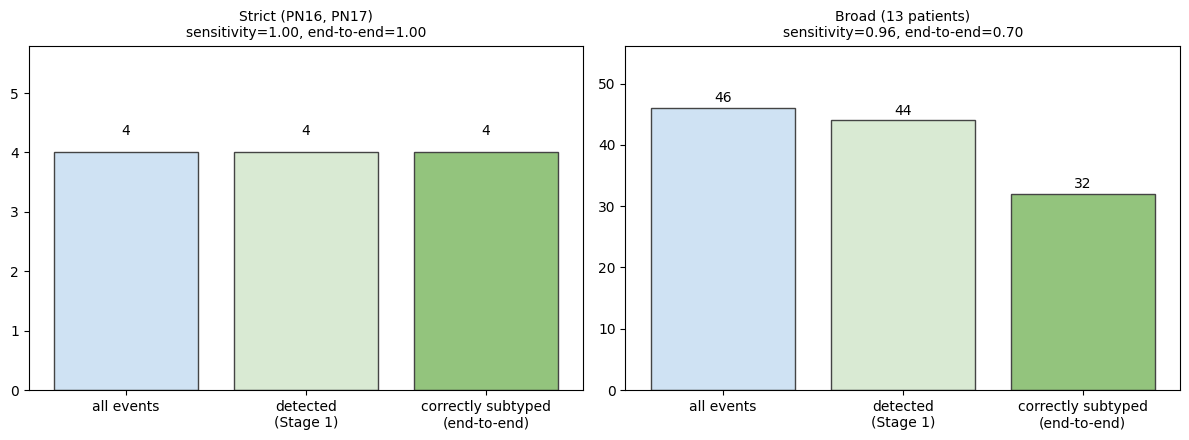

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, events, summary, title in [
    (axes[0], strict_events, strict_summary, "Strict (PN16, PN17)"),
    (axes[1], broad_events, broad_summary, "Broad (13 patients)"),
]:
    n = summary["n_events"]
    detected = int(events.detected.sum())
    correct = int(events.end_to_end_correct.sum())
    ax.bar(["all events", "detected\n(Stage 1)", "correctly subtyped\n(end-to-end)"],
           [n, detected, correct], color=["#cfe2f3", "#d9ead3", "#93c47d"], edgecolor="#444444")
    for i, v in enumerate([n, detected, correct]):
        ax.text(i, v + max(n * 0.02, 0.3), str(v), ha="center", fontsize=10)
    ax.set_title(f"{title}\nsensitivity={summary['sensitivity']:.2f}, end-to-end={summary['end_to_end_accuracy']:.2f}",
                 fontsize=10)
    ax.set_ylim(0, n * 1.2 + 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "cascade_funnel.png", dpi=130, bbox_inches="tight")
plt.show()


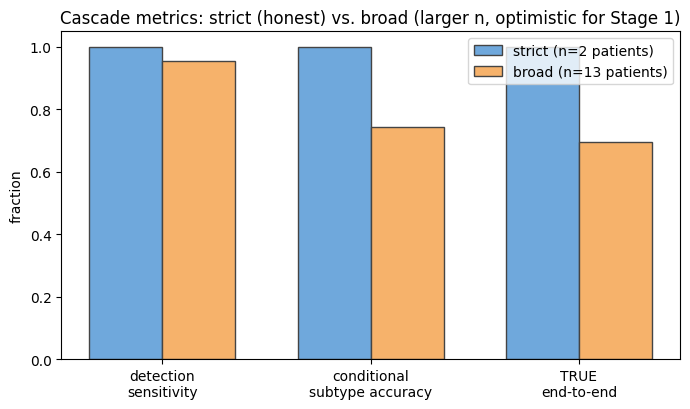

summary written to ..\checkpoints\cascade_end_to_end\cascade_summary.json


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.2))
groups = ["detection\nsensitivity", "conditional\nsubtype accuracy", "TRUE\nend-to-end"]
strict_vals = [strict_summary["sensitivity"], strict_summary["conditional_accuracy"], strict_summary["end_to_end_accuracy"]]
broad_vals = [broad_summary["sensitivity"], broad_summary["conditional_accuracy"], broad_summary["end_to_end_accuracy"]]
x = np.arange(len(groups))
w = 0.35
ax.bar(x - w / 2, strict_vals, w, label="strict (n=2 patients)", color="#6fa8dc", edgecolor="#444444")
ax.bar(x + w / 2, broad_vals, w, label="broad (n=13 patients)", color="#f6b26b", edgecolor="#444444")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylim(0, 1.05); ax.set_ylabel("fraction")
ax.set_title("Cascade metrics: strict (honest) vs. broad (larger n, optimistic for Stage 1)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "cascade_metrics_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

json.dump({"strict": strict_summary, "broad": broad_summary},
          open(OUT_DIR / "cascade_summary.json", "w"), indent=2)
print(f"summary written to {OUT_DIR / 'cascade_summary.json'}")


## Notes

- **The strict result is n=2 patients.** Read it as "the wiring works and produces a
  plausible number," not as a validated end-to-end accuracy estimate -- that would need
  materially more doubly-held-out patients than this project's data has.
- **The broad result is optimistic about Stage 1**, not Stage 2: 9 of 13 patients were in
  Stage 1's own training set, 2 more in its validation set. Its detection sensitivity here is
  not a fair test of Stage 1 in isolation (see `model_stage1_cnn1d_detection.ipynb` for that);
  it *is* a fair test of Stage 2's conditional accuracy and of the cascade mechanics, since
  every patient's Stage 2 prediction still comes from the LOSO fold that held *that* patient
  out.
- **Stage 2's conditional accuracy should roughly match its standalone LOSO numbers** for the
  same patients -- by design, Stage 1 only gates whether Stage 2 runs, it never changes what
  Stage 2 sees. A large gap between the two would indicate a bug in this notebook, not a real
  effect.
- **The false-positive probe is the other half of the honest picture.** Stage 2 has no
  "not a seizure" class -- handed a false alarm, it always answers with a confident subtype.
  A real deployment needs Stage 1's precision (not just sensitivity) to be trustworthy before
  any cascade like this is meaningful, and/or a confidence threshold on Stage 2's own output.